# <font color="brown">Insurance Claim Fraud Detection (Imbalanced Data) </font>

## <font color = "brown">Problem Statement </font>

### <font color="blue"> Context

An insurer has 8,000 recent claims, and only about 1 in 19 of them (5.3%) turned out to be fraudulent, confirmed after investigation. The fraud team wants a model to flag suspicious claims for review. A colleague already tried a plain classifier and reported "95% accuracy", and management is happy, but the fraud team suspects that number is hiding something important.

### <font color="blue"> Objective

- Show concretely why accuracy is the wrong metric to trust on data this imbalanced.
- Compare the standard toolbox for imbalanced classification, class weighting, random oversampling, random undersampling, and SMOTE, honestly, on more than one metric.
- Check a claim that's easy to overlook: are these techniques actually teaching the model something new, or just moving where it draws the line?

### <font color="blue"> Data Dictionary

- **Claim_ID**: unique identifier
- **Policy_Tenure_Months**: how long the policy has been active
- **Premium_Amount**: the policy's premium (USD)
- **Claim_Amount**: the amount claimed (USD)
- **Num_Prior_Claims**: prior claims filed by this customer
- **Claim_Response_Days**: days between the incident and the claim being filed
- **Customer_Age**: customer age in years
- **Fraud**: 1 if the claim was confirmed fraudulent, 0 otherwise (target)

## <font color="brown"> Importing Necessary Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay,
)
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

%matplotlib inline

## <font color="brown"> Reading and Understanding the Data

In [2]:
df = pd.read_csv("insurance_claims.csv")
df.shape

(8000, 8)

In [3]:
df.head()

,Claim_ID,Policy_Tenure_Months,Premium_Amount,Claim_Amount,Num_Prior_Claims,Claim_Response_Days,Customer_Age,Fraud
0,900001,11.1,544.98,2334.02,1,2.3,59,0
1,900002,46.9,460.08,3141.73,0,2.1,50,0
2,900003,183.9,951.49,3767.05,1,2.7,18,0
3,900004,7.3,1232.05,1260.60,2,5.8,46,0
4,900005,99.0,1061.18,2048.22,2,0.1,54,0


In [4]:
df["Fraud"].value_counts()

Fraud
0    7574
1     426
Name: count, dtype: int64

In [5]:
df["Fraud"].value_counts(normalize=True).round(4)

Fraud
0    0.9468
1    0.0532
Name: proportion, dtype: float64

**Only 5.3% of claims (426 out of 8,000) are fraudulent.** This is a genuinely imbalanced problem, not a minor skew, and it changes which metrics can be trusted.

## <font color="brown"> Part 1: The Accuracy Trap

Before building anything, consider the simplest possible “model”: never flag a single claim as fraud.

In [6]:
X = df.drop(columns=["Claim_ID", "Fraud"])
y = df["Fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y
)

naive_preds = np.zeros(len(y_test))
print("Naive 'always predict not-fraud' accuracy:", round(accuracy_score(y_test, naive_preds), 4))
print("Naive recall on actual fraud:", recall_score(y_test, naive_preds))

Naive 'always predict not-fraud' accuracy: 0.9467
Naive recall on actual fraud: 0.0


**94.7% accuracy, while catching exactly zero fraud cases.** This is the accuracy trap: when one class is rare, a model can score extremely well on accuracy while being completely useless at the one thing it's actually meant to do. On imbalanced data, accuracy must be dropped as the headline metric entirely, in favor of recall (are we catching the fraud?), precision (are our alerts worth investigating?), and ROC-AUC / PR-AUC (is the model any good at ranking risk at all, regardless of threshold?).

## <font color="brown"> Part 2: A Plain Model, No Adjustment

In [7]:
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

lr_plain = LogisticRegression(max_iter=1000, random_state=1)
lr_plain.fit(X_train_s, y_train)

pred_plain = lr_plain.predict(X_test_s)
proba_plain = lr_plain.predict_proba(X_test_s)[:, 1]

In [8]:
def evaluate(y_true, pred, proba):
    return {
        "Accuracy": accuracy_score(y_true, pred),
        "Recall": recall_score(y_true, pred),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred),
        "ROC_AUC": roc_auc_score(y_true, proba),
        "PR_AUC": average_precision_score(y_true, proba),
    }

results = {"Plain (no adjustment)": evaluate(y_test, pred_plain, proba_plain)}
pd.DataFrame(results).T.round(3)

,Accuracy,Recall,Precision,F1,ROC_AUC,PR_AUC
Plain (no adjustment),0.955,0.25,0.727,0.372,0.885,0.482


Better than the naive baseline, the model has clearly learned something (ROC-AUC of 0.885 is solid), but at the default 0.5 threshold it still only catches about 1 in 4 actual fraud cases (recall ≈ 0.25). For a fraud team, missing 75% of fraud is not a usable model, no matter how good the overall accuracy or ROC-AUC looks.

## <font color="brown"> Part 3: The Imbalanced-Data Toolbox

Four standard techniques address this. All change *how the model is trained* (or how its output is weighted), not the underlying data-generating problem itself:

### <font color="blue"> 1. Class Weighting

Tell the model to penalize a missed fraud case much more heavily than a false alarm, no resampling of the data at all:

In [9]:
lr_cw = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=1)
lr_cw.fit(X_train_s, y_train)
pred_cw = lr_cw.predict(X_test_s)
proba_cw = lr_cw.predict_proba(X_test_s)[:, 1]
results["Class Weighting"] = evaluate(y_test, pred_cw, proba_cw)
pd.DataFrame(results).T.round(3)

,Accuracy,Recall,Precision,F1,ROC_AUC,PR_AUC
Plain (no adjustment),0.955,0.250,0.727,0.372,0.885,0.482
Class Weighting,0.821,0.812,0.204,0.326,0.892,0.463


### <font color="blue"> 2. Random Oversampling

Duplicate minority-class (fraud) rows in the training set until both classes are equally represented:

In [10]:
ros = RandomOverSampler(random_state=1)
X_ros, y_ros = ros.fit_resample(X_train_s, y_train)
print("Training set size after oversampling:", len(y_ros), " fraud cases:", y_ros.sum())

lr_ros = LogisticRegression(max_iter=1000, random_state=1)
lr_ros.fit(X_ros, y_ros)
pred_ros = lr_ros.predict(X_test_s)
proba_ros = lr_ros.predict_proba(X_test_s)[:, 1]
results["Random Oversampling"] = evaluate(y_test, pred_ros, proba_ros)
pd.DataFrame(results).T.round(3)

Training set size after oversampling: 10604  fraud cases: 5302


,Accuracy,Recall,Precision,F1,ROC_AUC,PR_AUC
Plain (no adjustment),0.955,0.250,0.727,0.372,0.885,0.482
Class Weighting,0.821,0.812,0.204,0.326,0.892,0.463
Random Oversampling,0.822,0.820,0.206,0.329,0.892,0.462


### <font color="blue"> 3. Random Undersampling

The opposite: throw away majority-class (non-fraud) rows until both classes match the minority count:

In [11]:
rus = RandomUnderSampler(random_state=1)
X_rus, y_rus = rus.fit_resample(X_train_s, y_train)
print("Training set size after undersampling:", len(y_rus), " fraud cases:", y_rus.sum())

lr_rus = LogisticRegression(max_iter=1000, random_state=1)
lr_rus.fit(X_rus, y_rus)
pred_rus = lr_rus.predict(X_test_s)
proba_rus = lr_rus.predict_proba(X_test_s)[:, 1]
results["Random Undersampling"] = evaluate(y_test, pred_rus, proba_rus)
pd.DataFrame(results).T.round(3)

Training set size after undersampling: 596  fraud cases: 298


,Accuracy,Recall,Precision,F1,ROC_AUC,PR_AUC
Plain (no adjustment),0.955,0.250,0.727,0.372,0.885,0.482
Class Weighting,0.821,0.812,0.204,0.326,0.892,0.463
Random Oversampling,0.822,0.820,0.206,0.329,0.892,0.462
Random Undersampling,0.828,0.797,0.208,0.330,0.886,0.447


### <font color="blue"> 4. SMOTE (Synthetic Minority Oversampling)

Rather than duplicating existing fraud cases exactly, SMOTE creates new, synthetic fraud examples by interpolating between real fraud cases and their nearest fraud neighbors:

In [12]:
smote = SMOTE(random_state=1)
X_sm, y_sm = smote.fit_resample(X_train_s, y_train)
print("Training set size after SMOTE:", len(y_sm), " fraud cases:", y_sm.sum())

lr_sm = LogisticRegression(max_iter=1000, random_state=1)
lr_sm.fit(X_sm, y_sm)
pred_sm = lr_sm.predict(X_test_s)
proba_sm = lr_sm.predict_proba(X_test_s)[:, 1]
results["SMOTE"] = evaluate(y_test, pred_sm, proba_sm)
pd.DataFrame(results).T.round(3)

Training set size after SMOTE: 10604  fraud cases: 5302


,Accuracy,Recall,Precision,F1,ROC_AUC,PR_AUC
Plain (no adjustment),0.955,0.250,0.727,0.372,0.885,0.482
Class Weighting,0.821,0.812,0.204,0.326,0.892,0.463
Random Oversampling,0.822,0.820,0.206,0.329,0.892,0.462
Random Undersampling,0.828,0.797,0.208,0.330,0.886,0.447
SMOTE,0.830,0.805,0.211,0.335,0.893,0.457


## <font color="brown"> Comparing All Five, Honestly

In [13]:
comparison = pd.DataFrame(results).T.round(3)
comparison

,Accuracy,Recall,Precision,F1,ROC_AUC,PR_AUC
Plain (no adjustment),0.955,0.250,0.727,0.372,0.885,0.482
Class Weighting,0.821,0.812,0.204,0.326,0.892,0.463
Random Oversampling,0.822,0.820,0.206,0.329,0.892,0.462
Random Undersampling,0.828,0.797,0.208,0.330,0.886,0.447
SMOTE,0.830,0.805,0.211,0.335,0.893,0.457


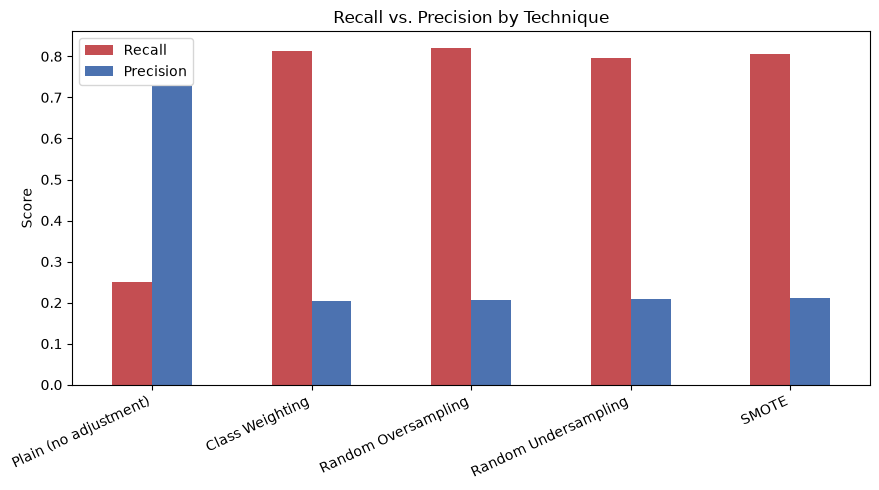

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
comparison[["Recall", "Precision"]].plot.bar(ax=ax, color=["#C44E52", "#4C72B0"])
ax.set_title("Recall vs. Precision by Technique")
ax.set_ylabel("Score")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

All four techniques tell essentially the same story: recall jumps from ~25% to ~80%, at the cost of precision dropping sharply (many more false alarms per real fraud caught). Notice something else, though: **ROC-AUC barely moves between any of these techniques (0.885–0.893)**. If class weighting, oversampling, undersampling, and SMOTE were teaching the model something genuinely new, we'd expect ROC-AUC, which measures ranking quality independent of any threshold, to improve meaningfully. It doesn't (0.885 for the plain model vs. 0.886–0.893 for the four techniques). That's a clue worth chasing.

## <font color="brown"> Part 4: What Are These Techniques Actually Doing?

A natural hypothesis: for a linear model like logistic regression, class weighting and resampling aren't adding new information, they're mainly shifting *where the model's default decision threshold effectively sits*. Let's test that directly: take the **plain** model from Part 2 (never resampled, never reweighted) and simply lower its classification threshold until it reaches the same recall the class-weighted model achieved.

In [15]:
target_recall = recall_score(y_test, pred_cw)
fpr, tpr, thresholds = roc_curve(y_test, proba_plain)
idx = np.argmin(np.abs(tpr - target_recall))
matched_threshold = thresholds[idx]

pred_plain_matched = (proba_plain >= matched_threshold).astype(int)

print(f"Target recall (from class-weighted model): {target_recall:.3f}")
print(f"Plain model, threshold lowered to {matched_threshold:.4f}:")
print(f"  recall:    {recall_score(y_test, pred_plain_matched):.3f}")
print(f"  precision: {precision_score(y_test, pred_plain_matched):.3f}")
print()
print(f"Class-weighted model (for comparison):")
print(f"  recall:    {recall_score(y_test, pred_cw):.3f}")
print(f"  precision: {precision_score(y_test, pred_cw):.3f}")

Target recall (from class-weighted model): 0.812
Plain model, threshold lowered to 0.0507:
  recall:    0.812
  precision: 0.197

Class-weighted model (for comparison):
  recall:    0.812
  precision: 0.204


**Nearly identical.** Just moving the plain model's decision threshold down to 0.051 reproduces essentially the same recall/precision tradeoff that class weighting achieved through an entirely different mechanism (reweighting the training loss). For a linear model, this is expected: class weighting and resampling mostly change *where* the model's probability output crosses into a “fraud” prediction, not the underlying probabilities themselves, which is exactly why ROC-AUC (threshold-independent) barely moved in the comparison above. **This does not mean these techniques are useless, it means their main value, for a linear model, is convenience: they save you from manually threshold-searching, and for other model families (tree ensembles especially), resampling can also change what splits the model considers during training itself, a genuinely different effect that plain threshold-tuning cannot reproduce.**

## <font color="brown"> Precision-Recall Curve: The Right Visual for Imbalanced Data

ROC curves can look deceptively good on imbalanced data (the large majority class makes the false-positive rate axis easy to keep low). A precision-recall curve is more honest here, it shows directly what precision costs at every possible recall level:

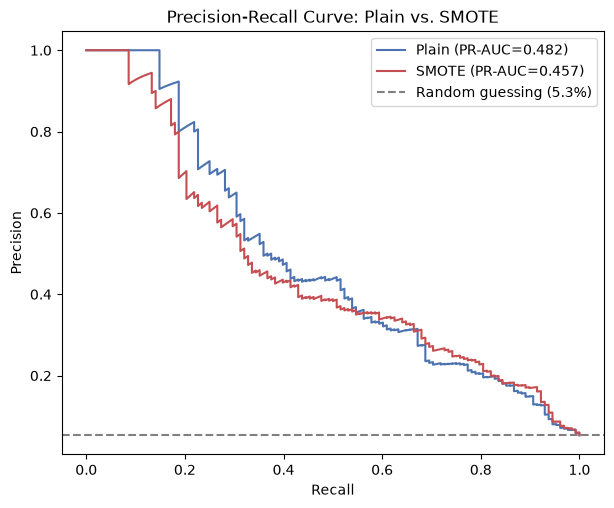

In [16]:
prec_plain, rec_plain, _ = precision_recall_curve(y_test, proba_plain)
prec_sm, rec_sm, _ = precision_recall_curve(y_test, proba_sm)

plt.figure(figsize=(7, 5.5))
plt.plot(rec_plain, prec_plain, label=f"Plain (PR-AUC={results['Plain (no adjustment)']['PR_AUC']:.3f})", color="#4C72B0")
plt.plot(rec_sm, prec_sm, label=f"SMOTE (PR-AUC={results['SMOTE']['PR_AUC']:.3f})", color="#C44E52")
baseline_rate = y_test.mean()
plt.axhline(baseline_rate, linestyle="--", color="gray", label=f"Random guessing ({baseline_rate:.1%})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve: Plain vs. SMOTE")
plt.legend()
plt.show()

Both curves trace nearly the same shape, further confirming that SMOTE hasn't fundamentally changed the model's underlying ability to separate fraud from non-fraud, it has the same ranking quality as the plain model, just evaluated (and by default thresholded) differently. Both curves sit far above the random-guessing baseline (5.3% precision at every recall level), confirming the model has learned a real, useful signal.

## <font color="brown"> A Closer Look: Confusion Matrix at a Chosen Operating Point

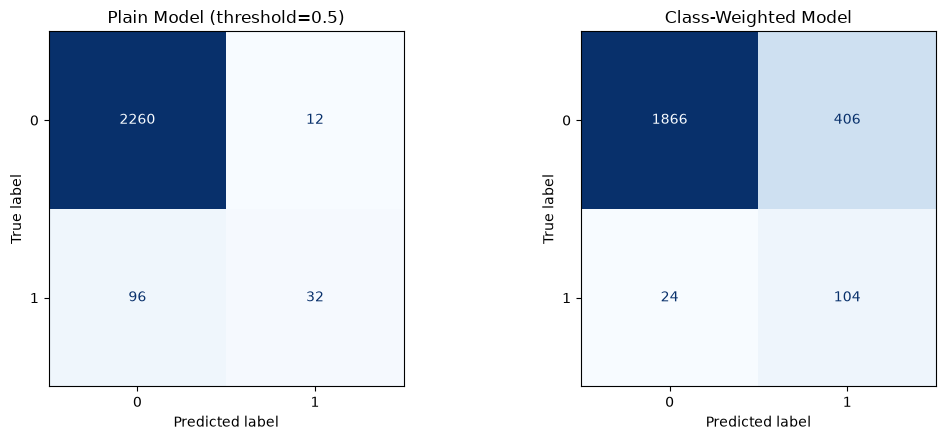

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_plain, ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Plain Model (threshold=0.5)")
ConfusionMatrixDisplay.from_predictions(y_test, pred_cw, ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("Class-Weighted Model")
plt.tight_layout()
plt.show()

The plain model misses far more actual fraud cases (bottom-left cell) than the class-weighted model, at the cost of the class-weighted model raising more false alarms (top-right cell). Which tradeoff is right depends entirely on the business cost of each type of mistake, a missed fraud vs. an investigator's time on a false alarm, a decision for the fraud team, not something a single metric can settle on its own.

## <font color="brown"> Business Insights and Recommendations

- **The “95% accuracy” that impressed management was catching zero fraud cases.** Any imbalanced-data project must lead with recall, precision, and ROC/PR-AUC, never accuracy alone, this is not a minor caveat, it can completely invert whether a model is useful.

- **Class weighting, random oversampling, random undersampling, and SMOTE all produced a similar, large recall improvement** (about 25% → 80%), at a similar precision cost. For this linear model, none had a meaningful edge over the others in ROC-AUC or PR-AUC.

- **The real mechanism behind that improvement, for this model, was mostly a shifted decision threshold, not new information.** Manually lowering the plain model's threshold reproduced nearly the same recall/precision tradeoff. Teams reaching for SMOTE by default should know a simpler threshold search on a plain model can often get most of the same result, with less complexity and no risk of synthetic-data artifacts.

- **The final threshold is a business decision, not a modeling one.** It should be set from the real cost of a missed fraud versus the cost of an investigator's time on a false alarm, not left at the default 0.5 cutoff.

- **Resampling is not always just threshold-shifting in disguise**, that equivalence is a property of linear models like logistic regression specifically. For tree-based ensembles (Random Forest, Gradient Boosting), resampling changes which splits the model considers during training itself, a genuinely different mechanism worth re-testing this same comparison against, rather than assuming this case study's finding transfers automatically.